In [2]:
import os
import torch
import random
import librosa
import torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import classification_report, recall_score, f1_score
import time
import seaborn as sns
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score


RCNN combines CNN and RNNS i.e., LSTM or GRU
It is designed for sequential data where CNN extracts spatial features and the RNN learns temporal patterns.



In [3]:
df=pd.read_csv('/kaggle/input/datasets/victorolufemi/respimerge-5/unified_respiratory_data/metadata_handover.csv')

In [4]:
base_path='/kaggle/input/datasets/victorolufemi/respimerge-5/unified_respiratory_data/audio_files'


In [5]:
audio_data = {}  

for _, row in df.iterrows():
    file_path = os.path.join(base_path, row['file_id'])
    
    if os.path.exists(file_path):
        y, sr = librosa.load(file_path, sr=16000)
        audio_data[row['file_id']] = {'waveform': y, 'sr': sr}
    else:
        print("Missing file:", file_path)

In [6]:
def pad_audio(waveform,sr=16000,min_duration=1.5):
    """Pad short audio files with 0 ensuring uniform length"""
    target_size=int(sr* min_duration)
    if(len(waveform)<target_size):
        waveform=np.pad(waveform,(0,target_size-len(y)))
    return y,sr

In [7]:
def flatten_waveform(y):
    """
    Convert any nested structure (list, tuple, np.ndarray) to flat 1D float32 array
    """
    flat_list = []

    def _flatten(item):
        if isinstance(item, (list, tuple, np.ndarray)):
            for sub in item:
                _flatten(sub)
        else:
            flat_list.append(float(item))

    _flatten(y)
    return np.array(flat_list, dtype=np.float32)

In [8]:
TARGET_SR = 16000
TARGET_DURATION = 1.5
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

def process_audio(waveform, sr):
    # Ensure numpy 1D float32
    waveform = np.asarray(waveform, dtype=np.float32).flatten()

    # Resample FIRST
    if sr != TARGET_SR:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=TARGET_SR)
        sr = TARGET_SR

    #  Force exact same length
    if len(waveform) < TARGET_LENGTH:
        waveform = np.pad(waveform, (0, TARGET_LENGTH - len(waveform)))
    else:
        waveform = waveform[:TARGET_LENGTH]

    # Compute Mel
    mel = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    )

    log_mel = librosa.power_to_db(mel, ref=np.max)

    # Normalize
    log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-6)

    return log_mel.astype(np.float32)

In [9]:
# label normalization
df['label'] = df['label'].str.strip()      
df['label'] = df['label'].str.lower()     

In [10]:
from sklearn.preprocessing import LabelEncoder
# Fit label encoder once
label_encoder = LabelEncoder()
label_encoder.fit(df['label'])

X = []
y_labels = []

for _, row in df.iterrows():
    file_id = row['file_id']
    label_str = row['label']

    if file_id in audio_data:
        y = audio_data[file_id]['waveform']
        sr = audio_data[file_id]['sr']

        # Flatten waveform safely
        y = flatten_waveform(y)

        if y.size == 0:
            print(f"Skipping empty waveform: {file_id}")
            continue

        # Convert label string → integer
        label_int = label_encoder.transform([label_str])[0]
        label_tensor = torch.tensor(label_int, dtype=torch.long)

        # Process audio
        mel = process_audio(y, sr)
        mel = np.expand_dims(mel, axis=0)

        mel_tensor = torch.tensor(mel, dtype=torch.float32)

        X.append(mel_tensor)
        y_labels.append(label_tensor)



In [11]:
print(label_encoder.classes_)

['asthma' 'bronchitis' 'copd' 'healthy' 'pneumonia']


In [12]:
X = torch.stack(X) # shape: [N, 1, 128, frames]
y_labels = torch.stack(y_labels)  # shape: [N]

In [13]:
X.shape

torch.Size([1211, 1, 128, 47])

In [14]:
print(y_labels.shape)
print(X.shape)

torch.Size([1211])
torch.Size([1211, 1, 128, 47])


In [15]:
def spec_augment(mel_spectrogram, freq_mask_param=30, time_mask_param=40):
    """Apply SpecAugment on (C, F, T) spectrogram"""
    C, F, T = mel_spectrogram.shape

    # Frequency masking
    freq_mask = np.random.randint(0, freq_mask_param)
    if freq_mask > 0:
        freq_start = np.random.randint(0, F - freq_mask)
        mel_spectrogram[:, freq_start:freq_start+freq_mask, :] = 0

    # Time masking
    time_mask = np.random.randint(0, time_mask_param)
    if time_mask > 0:
        time_start = np.random.randint(0, T - time_mask)
        mel_spectrogram[:, :, time_start:time_start+time_mask] = 0

    return mel_spectrogram

In [17]:
class AudioDataset(Dataset):
    def __init__(self, X, y, apply_specaugment=True):
        self.X = X
        self.y = y
        self.apply_specaugment = apply_specaugment
    
    def __getitem__(self, idx):
        mel_spec = self.X[idx].copy()
        label = self.y[idx]
        
        if self.apply_specaugment:
            mel_spec = spec_augment(mel_spec, freq_mask_param=10, time_mask_param=15)
        
        return torch.tensor(mel_spec, dtype=torch.float32), \
               torch.tensor(label, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)

In [18]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_labels,
    test_size=0.3,
    stratify=y_labels,
    random_state=42
)

# Split 2: validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,   # Half of 30% → 15%
    stratify=y_temp,
    random_state=42
)

In [19]:
X_train_np = X_train.cpu().numpy() if isinstance(X_train, torch.Tensor) else X_train
y_train_np = y_train.cpu().numpy() if isinstance(y_train, torch.Tensor) else y_train
X_val_np = X_val.cpu().numpy() if isinstance(X_val, torch.Tensor) else X_val
y_val_np = y_val.cpu().numpy() if isinstance(y_val, torch.Tensor) else y_val
X_test_np = X_test.cpu().numpy() if isinstance(X_test, torch.Tensor) else X_test
y_test_np = y_test.cpu().numpy() if isinstance(y_test, torch.Tensor) else y_test

In [21]:
train_dataset = AudioDataset(X_train_np, y_train_np, apply_specaugment=True)
val_dataset = AudioDataset(X_val_np, y_val_np, apply_specaugment=False)
test_dataset = AudioDataset(X_test_np, y_test_np, apply_specaugment=False)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [22]:
for batch_X, batch_y in train_loader:
    print(batch_X.shape)  # [batch_size, 1, 128, 47]
    print(batch_y.shape)  # [batch_size]
    break

torch.Size([32, 1, 128, 47])
torch.Size([32])


In [23]:
import torch.nn as nn

class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()

        # CNN part
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.dropout=nn.Dropout(0.3)

        # RNN part
        self.rnn = nn.LSTM(
            input_size=64 * 32, 
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        # Classification
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)

        # x shape: (batch, channels, freq, time)
        b, c, f, t = x.size()

        # reshape for RNN
        x = x.permute(0, 3, 1, 2)  # (batch, time, channels, freq)
        x = x.contiguous().view(b, t, c * f)
        x=self.dropout(x)
        x, _ = self.rnn(x)

        # Take last time step
        x = x[:, -1, :]

        x = self.fc(x)

        return x

In [24]:
from sklearn.utils.class_weight import compute_class_weight

y_numpy = y_labels.numpy()  # shape [num_samples]

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_numpy),
    y=y_numpy
)

class_weights = torch.tensor(class_weights, dtype=torch.float32)

print(class_weights)

tensor([0.8410, 2.3288, 0.6040, 1.8211, 0.8498])


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CRNN(num_classes=5).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [26]:
num_epochs = 50
train_losses = []
val_losses = []
val_recalls = []
val_f1s = []
best_val_loss = float('inf')
patience = 10
counter = 0


start_train = time.perf_counter()

for epoch in range(num_epochs):
    # Training 
    model.train()
    total_train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    total_val_loss = 0
    val_preds = []
    val_true = []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()
            
            val_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            val_true.extend(targets.cpu().numpy())
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_loss = avg_val_loss
    val_recall = recall_score(val_true, val_preds, average='weighted', zero_division=0)
    val_f1 = f1_score(val_true, val_preds, average='weighted', zero_division=0)
    
    val_losses.append(avg_val_loss)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Recall: {val_recall:.4f} | "
          f"Val F1: {val_f1:.4f}")
    
    # Early stopping based on validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
    
    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break


end_train = time.perf_counter()
training_time = end_train - start_train
print(f"\nTotal Training Time: {training_time:.2f} seconds")


Epoch [1/50] Train Loss: 1.4979 | Val Loss: 1.3051 | Val Recall: 0.3516 | Val F1: 0.2391
Epoch [2/50] Train Loss: 1.3184 | Val Loss: 1.1842 | Val Recall: 0.4835 | Val F1: 0.4376
Epoch [3/50] Train Loss: 1.2297 | Val Loss: 1.0495 | Val Recall: 0.6538 | Val F1: 0.6274
Epoch [4/50] Train Loss: 1.1476 | Val Loss: 0.9596 | Val Recall: 0.6703 | Val F1: 0.6708
Epoch [5/50] Train Loss: 1.1386 | Val Loss: 0.9451 | Val Recall: 0.7308 | Val F1: 0.7156
Epoch [6/50] Train Loss: 1.0703 | Val Loss: 0.9635 | Val Recall: 0.6978 | Val F1: 0.6742
Epoch [7/50] Train Loss: 1.0273 | Val Loss: 0.9340 | Val Recall: 0.6209 | Val F1: 0.5940
Epoch [8/50] Train Loss: 0.9649 | Val Loss: 0.8655 | Val Recall: 0.7088 | Val F1: 0.6988
Epoch [9/50] Train Loss: 0.9457 | Val Loss: 0.7804 | Val Recall: 0.6978 | Val F1: 0.6992
Epoch [10/50] Train Loss: 0.9030 | Val Loss: 0.7732 | Val Recall: 0.7198 | Val F1: 0.7211
Epoch [11/50] Train Loss: 0.8443 | Val Loss: 0.7266 | Val Recall: 0.7088 | Val F1: 0.7114
Epoch [12/50] Train

In [27]:
# Evaluation

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

test_preds = []
test_true = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        test_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        test_true.extend(targets.cpu().numpy())

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Test Recall (weighted): {recall_score(test_true, test_preds, average='weighted'):.4f}")
print(f"Test F1-Score (weighted): {f1_score(test_true, test_preds, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(test_true, test_preds, 
                          target_names=['Asthma', 'Bronchitis', 'COPD', 'Healthy', 'Pneumonia']))



TEST SET RESULTS
Test Recall (weighted): 0.8407
Test F1-Score (weighted): 0.8409

Classification Report:
              precision    recall  f1-score   support

      Asthma       0.78      0.91      0.84        44
  Bronchitis       0.93      0.87      0.90        15
        COPD       0.91      0.87      0.89        60
     Healthy       0.71      0.85      0.77        20
   Pneumonia       0.86      0.72      0.78        43

    accuracy                           0.84       182
   macro avg       0.84      0.84      0.84       182
weighted avg       0.85      0.84      0.84       182



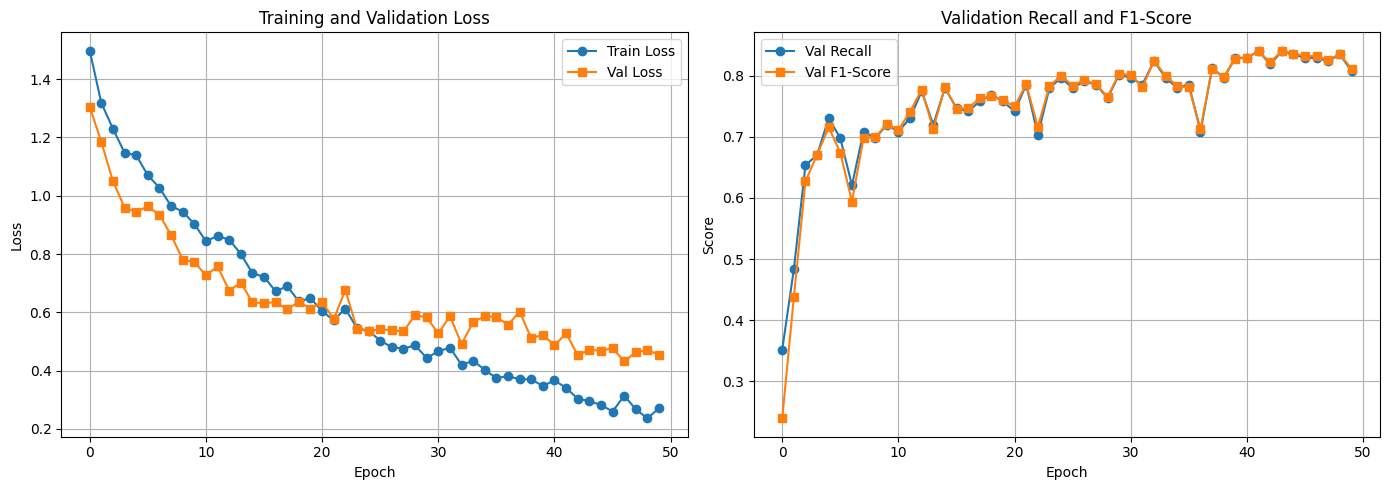


 Best model saved to 'best_model.pth'
 Training metrics plot saved to 'training_metrics.png'


In [31]:


# -------------------
# Visualization
# -------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Recall and F1 curves
axes[1].plot(val_recalls, label='Val Recall', marker='o')
axes[1].plot(val_f1s, label='Val F1-Score', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Recall and F1-Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Best model saved to 'best_model.pth'")
print(f" Training metrics plot saved to 'training_metrics.png'")

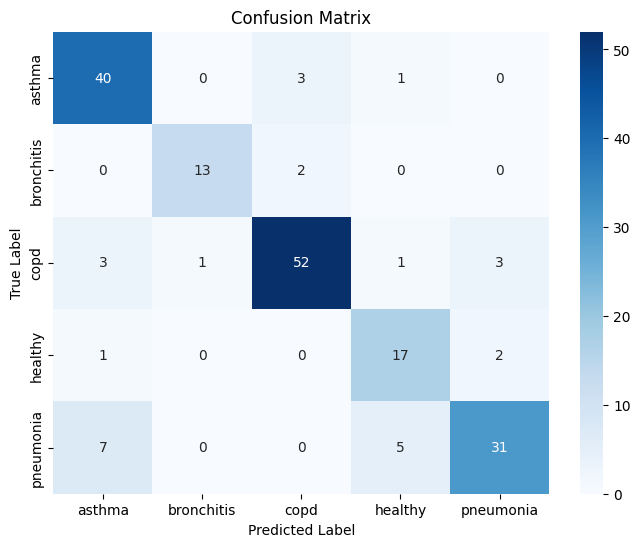

In [32]:
# Confusion matrix
cm = confusion_matrix(test_true, test_preds, labels=[0,1,2,3,4])

class_names = ['asthma', 'bronchitis', 'copd', 'healthy', 'pneumonia']


plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## Pneumonia:
- 31 correctly predicted as Pneumonia
- 7 misclassified as Asthma
- 5 misclassified as Healthy

Pneumonia is often confused with Asthma and Healthy, which lowers recall

## Asthma mostly correct:
- 40 out of 44 predicted correctly; 3 misclassified as COPD and 1 as Healthy.

## Bronchitis fairly clean:

- 13 out of 15 correct; 2 misclassified as COPD.
  
## COPD mostly correct:
- 52 out of 60 correct; small confusion with 3 Asthma, 1 Bronchitis, and 3 Pneumonia.
## Healthy somewhat confused:
- 17 out of 20 correct; 2 misclassified as Pneumonia and 1 as Asthma
